# 2024 Italian GP(Monza) - Strategy Post Mortem: Betting Against the Field

## The Racing Question:
Every front running strategy in this race started the same way, a Medium-tire stint, and then a stop. But Leclerc pivoted to a one-stop while Piastri and the rest of the field committed to two. Leclerc won by 2.664 seconds. How did betting against the grid's shared plan pay off, and how close did it actually come to failing?

## What Happened:
- Lap 15: Leclerc pits from P2, the only car stopping at this exact moment which then causes him to drop to P7(pit-stop cost), a bigger loss than a shared-caution stop would cost, since no one else is pitting alongside him.
- Lap 16: Piastri makes his first stop(a conventional stop, still planning for two stops), briefly cedeing the lead before reclaiming it once the pit cycle settled.
- Laps 16-37: Leclerc climbs steadily back through the field( P7 --> P3 --> P2) purely as other cars complete their own stops. He is running a single set of tires far longer than anyone else in the front. 
- Lap 38: Piastri makes his second stop, as planned under McLaren's two-stop strategy. This is the decisive moment: Leclerc is still on his second stint tires(now 23 laps old), inherits the outright race lead the instant Piastri's second stop begins.
- Laps 39-53: Position holds(Leclerc P1 & Piastri P2) for the remainder, but the gap narrows dramatically as Piatri's fresh Hards(fitted lap 39 vs. Leclerc's Hards fitted at lap 15) close in. The gap shrinks from over 18 seconds in Leclerc's favor to just 2.664 seconds by the checkered flag.

## Why It Matters:
The one-stop strategy wasn't a single decision that immediately won the race, it was a bet that had to survive nearly 40 laps of running on increasingly old tires while rest of the field pitted twice. The payoff only arrived at the very moment Piastri's own second stop happened, and even then, Leclerc's tire deficit was severe enough that Piastri nearly closed the entire gap in the final 15 laps. This was legitimately a close call, not a clean, comfortable strategic win; the race margin at the checkered flag(2.664 seconds) makes it clear. 

## Strategist Takeaway:
A contrarian strategy against the whole grid isn't validated the moment you make the call, it's validated only when it survives contact with everyone else's plan. Ferrari had to trust that 38+ laps on one set of tires would hold up well enough to still be racing for the win once the position swap finally arrived, and that the fresh-tire rival(Piastri in this case) chasing afterward wouldn't have enough laps left to complete the catch. Both bets nearly failed; both barely paid off.

## A Note on Method:
The gap chart's sign convention was initially backwards for the second time in this project(similar to the error in the 2021 Turkish GP), the chart's shape was correct but the label accidently claimed Piastri was ahead when Leclerc was actually leading. This was caught by cross-checking the final gap value(+2.7s) against the real, known result that Leclerc won the Grand Prix by 2.664 seconds; it was then confirmed directly against 'Position' data. A seperate check of the full position trace(not just the gap between the two drivers) also revealed a richer story than what the gap chart showed alone: Leclerc did not immediately take the lead after his pit stop, but only 23 laps later, once Piastri's second stop forced the swap.  

In [1]:
#imports

import fastf1
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
fastf1.Cache.enable_cache('../data/cache')

session = fastf1.get_session(2024, 'Monza', 'R')
session.load()

print(session.event['EventName'])
print(session.event['EventDate'])

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

Italian Grand Prix
2024-09-01 00:00:00


In [7]:
# Getting lap data for Leclerc & Piastri

laps = session.laps

lec_laps = laps.pick_drivers('LEC')
pia_laps = laps.pick_drivers('PIA')

print("Leclerc Laps:")
print(len(lec_laps))

print("Piastri Laps:")
print(len(pia_laps))

cols = ['LapNumber', 'LapTime', 'Compound', 'Stint', 'PitInTime', 'PitOutTime', 'TrackStatus']

Leclerc Laps:
53
Piastri Laps:
53


In [8]:
#getting pitstops for Leclerc & Piastri

lec_pit_laps = lec_laps[lec_laps['PitInTime'].notna()]
pia_pit_laps = pia_laps[pia_laps['PitInTime'].notna()]

print("Leclerc Pit stops:")
print(lec_pit_laps[cols])

print("\nPiastri Pit stops:")
print(pia_pit_laps[cols])

Leclerc Pit stops:
    LapNumber                LapTime Compound  Stint              PitInTime  \
14       15.0 0 days 00:01:30.192000   MEDIUM    1.0 0 days 01:17:08.772000   

   PitOutTime TrackStatus  
14        NaT           1  

Piastri Pit stops:
    LapNumber                LapTime Compound  Stint              PitInTime  \
68       16.0 0 days 00:01:29.939000   MEDIUM    1.0 0 days 01:18:30.160000   
90       38.0 0 days 00:01:28.125000     HARD    2.0 0 days 01:49:32.401000   

   PitOutTime TrackStatus  
68        NaT           1  
90        NaT           1  


In [9]:
#confirming Piastri's tire compound for the last stint

print(pia_laps[pia_laps['LapNumber'].isin([16, 38, 39])][['LapNumber', 'Compound']])

    LapNumber Compound
68       16.0   MEDIUM
90       38.0     HARD
91       39.0     HARD


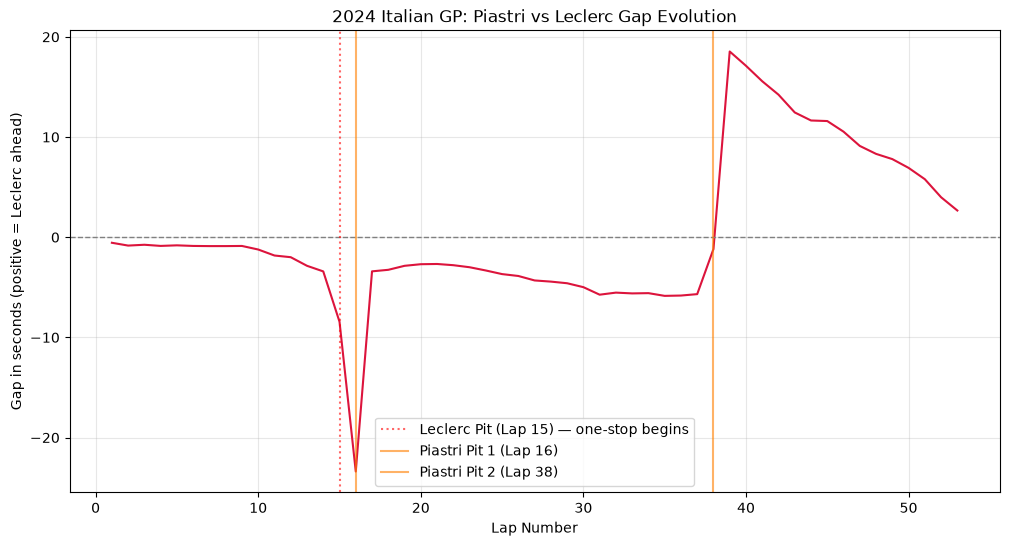

In [15]:
#Building a gap chart for Leclerc & Piastri

merged = pd.merge(
    lec_laps[['LapNumber', 'Time']],
    pia_laps[['LapNumber', 'Time']],
    on='LapNumber',
    suffixes=('_LEC', '_PIA')
)

merged['Gap_PIA_minus_LEC'] = (merged['Time_PIA'] - merged['Time_LEC']).dt.total_seconds()

plt.figure(figsize=(12, 6))
plt.plot(merged['LapNumber'], merged['Gap_PIA_minus_LEC'], color='#DC143C')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.axvline(15, color='red', linestyle=':', alpha=0.6, label='Leclerc Pit (Lap 15) — one-stop begins')
plt.axvline(16, color='#FF8000', linestyle='-', alpha=0.6, label='Piastri Pit 1 (Lap 16)')
plt.axvline(38, color='#FF8000', linestyle='-', alpha=0.6, label='Piastri Pit 2 (Lap 38)')

plt.xlabel('Lap Number')
plt.ylabel('Gap in seconds (positive = Leclerc ahead)')
plt.title('2024 Italian GP: Piastri vs Leclerc Gap Evolution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
#confirming Leclerc's position with respect to Piastri through positional data

check_laps = [1, 15, 20, 38, 45, 53]
lec_pos = lec_laps[lec_laps['LapNumber'].isin(check_laps)][['LapNumber', 'Position']]
pia_pos = pia_laps[pia_laps['LapNumber'].isin(check_laps)][['LapNumber', 'Position']]

print("Leclerc:\n", lec_pos)
print("\nPiastri:\n", pia_pos)

Leclerc:
     LapNumber  Position
0         1.0       2.0
14       15.0       3.0
19       20.0       5.0
37       38.0       2.0
44       45.0       1.0
52       53.0       1.0

Piastri:
      LapNumber  Position
53         1.0       1.0
67        15.0       1.0
72        20.0       3.0
90        38.0       1.0
97        45.0       2.0
105       53.0       2.0


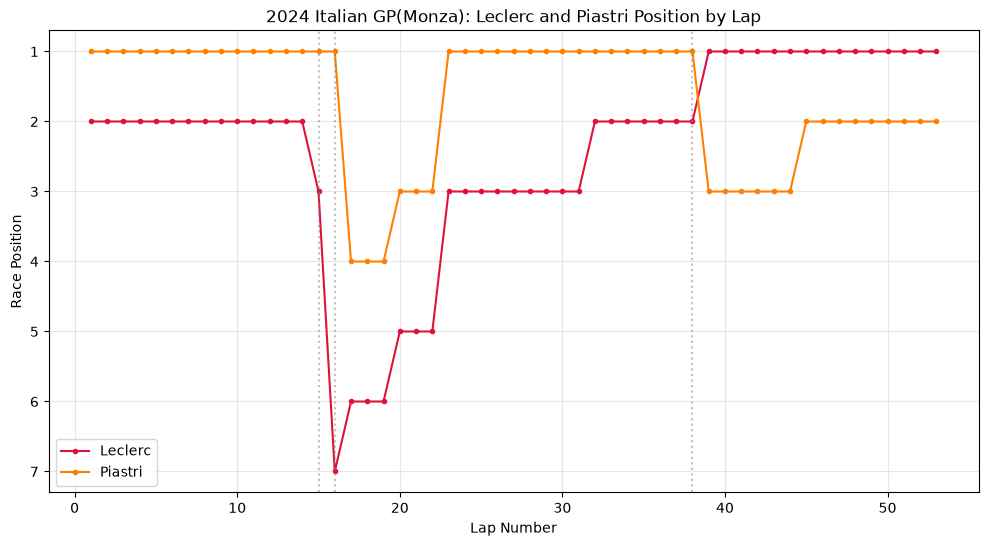

In [14]:
#Building a position chart for Leclerc & Piastri

plt.figure(figsize=(12, 6))
plt.plot(lec_laps['LapNumber'], lec_laps['Position'], color='#DC143C', marker='o', markersize=3, label='Leclerc')
plt.plot(pia_laps['LapNumber'], pia_laps['Position'], color='#FF8000', marker='o', markersize=3, label='Piastri')

plt.gca().invert_yaxis()
plt.axvline(15, color='gray', linestyle=':', alpha=0.5)
plt.axvline(16, color='gray', linestyle=':', alpha=0.5)
plt.axvline(38, color='gray', linestyle=':', alpha=0.5)

plt.xlabel('Lap Number')
plt.ylabel('Race Position')
plt.title('2024 Italian GP(Monza): Leclerc and Piastri Position by Lap')
plt.legend()
plt.grid(alpha=0.3)
plt.show()